In [6]:
import numpy as np
import matplotlib.pyplot as plt

from cifar10_data_preprocessing import *

In [7]:
data_dir = 'cifar-10-batches-py'

# Load cifar-10 dataset.
train_data, train_labels, test_data, test_labels, label_names = load_cifar_10_data(data_dir)

# Shuffle the train_data and divide into train_data and dev_data.
dev_data, dev_labels, train_data, train_labels = split_dataset(train_data, train_labels, num_dev = 5000)

# Check the shape of train/dev/test data and number of classes.
print("Train data: ", train_data.shape)
print("Train labels: ", train_labels.shape)
print("Dev data: ", dev_data.shape)
print("Dev labels: ", dev_labels.shape)
print("Test data: ", test_data.shape)
print("Test labels: ", test_labels.shape)
print('Number of classes:', label_names.shape[0])

Train data:  (45000, 32, 32, 3)
Train labels:  (45000,)
Dev data:  (5000, 32, 32, 3)
Dev labels:  (5000,)
Test data:  (10000, 32, 32, 3)
Test labels:  (10000,)
Number of classes: 10


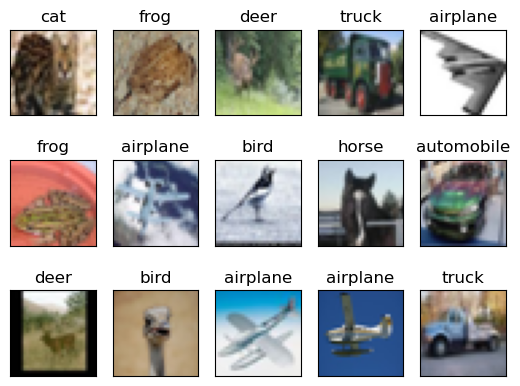

In [8]:
# Don't forget that the label_names and filesnames are in binary and need conversion if used.
classes = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])

# Display some random training images in a 3x5 grid
fig, ax = plt.subplots(3, 5)
for m in range(3):
    for n in range(5):
        idx = np.random.randint(0, train_data.shape[0])
        ax[m, n].set_title(classes[train_labels[idx]]) # display label
        ax[m, n].imshow(train_data[idx]) # display image data
        ax[m, n].get_xaxis().set_visible(False)
        ax[m, n].get_yaxis().set_visible(False)
plt.show()

In [9]:
# Convert label of each image data into one-hot vector(y). 
# Its length is the same as the number of classes.
y_train = one_hot_encoding(train_labels, classes)
y_dev = one_hot_encoding(dev_labels, classes)
y_test = one_hot_encoding(test_labels, classes)

print(y_train[0])
print(y_train.shape)


[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
(45000, 10)


In [10]:
# Normalize pixel values of input image from [0, 255] range to [0, 1] range.
x_train = normalize_image(train_data)
x_dev = normalize_image(dev_data)
x_test = normalize_image(test_data)

print(train_data[0]) # before normalization
print(x_train[0]) # after normalization

[[[ 77  77  77]
  [ 76  76  76]
  [ 79  79  79]
  ...
  [114 114 114]
  [116 116 116]
  [119 119 119]]

 [[ 81  81  81]
  [ 72  72  72]
  [ 59  59  59]
  ...
  [ 97  97  97]
  [104 104 104]
  [107 107 107]]

 [[ 83  83  83]
  [ 82  82  82]
  [ 72  72  72]
  ...
  [ 78  78  78]
  [ 93  93  93]
  [ 97  97  97]]

 ...

 [[ 31  31  31]
  [ 34  34  34]
  [ 34  34  34]
  ...
  [ 78  78  78]
  [ 79  79  79]
  [ 83  83  83]]

 [[ 38  38  38]
  [ 38  38  38]
  [ 36  36  36]
  ...
  [ 75  75  75]
  [ 80  80  80]
  [ 86  86  86]]

 [[ 54  54  54]
  [ 55  55  55]
  [ 59  59  59]
  ...
  [ 64  64  64]
  [ 64  64  64]
  [ 65  65  65]]]
[[[0.43421053 0.43421053 0.43421053]
  [0.42763158 0.42763158 0.42763158]
  [0.44736842 0.44736842 0.44736842]
  ...
  [0.67763158 0.67763158 0.67763158]
  [0.69078947 0.69078947 0.69078947]
  [0.71052632 0.71052632 0.71052632]]

 [[0.46052632 0.46052632 0.46052632]
  [0.40131579 0.40131579 0.40131579]
  [0.31578947 0.31578947 0.31578947]
  ...
  [0.56578947 0.5657894